# Análisis del Dataset_Balanceado_700

Este script cuenta cuántas imágenes hay por cada clase en el dataset `Dataset_Balanceado_700` y verifica sus dimensiones. 
Dado que los archivos son `.npz`, se itera sobre todos los archivos, se cargan y se suman las imágenes contenidas en cada uno.

In [1]:
import os
import numpy as np

# Ruta del dataset
dataset_path = 'Dataset_Balanceado_700'

if not os.path.exists(dataset_path):
    # Ajuste de ruta si se corre desde Propuesta1/
    if os.path.exists('../Dataset_Balanceado_700'):
        dataset_path = '../Dataset_Balanceado_700'
    else:
        print(f"Error: La carpeta '{dataset_path}' no se encuentra en el directorio actual.")

if os.path.exists(dataset_path):
    # Obtener las carpetas de las clases
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    
    print(f"{'Clase':<25} | {'Archivos':<10} | {'Total Imágenes':<15} | {'Dimensiones (WxH)':<20}")
    print("-" * 80)
    
    total_dataset_images = 0
    
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_dir) if f.lower().endswith('.npz')]
        
        num_files = len(files)
        total_class_images = 0
        dims_set = set()
        
        for file_name in files:
            file_path = os.path.join(class_dir, file_name)
            try:
                with np.load(file_path) as data:
                    # Basado en la salida anterior, la clave es 'imagenes'
                    if 'imagenes' in data:
                        imgs = data['imagenes']
                        # Asumimos formato (N, H, W) donde N es el numero de imagenes
                        n_imgs = imgs.shape[0]
                        total_class_images += n_imgs
                        
                        if len(imgs.shape) >= 3:
                             dims_set.add(f"{imgs.shape[2]}x{imgs.shape[1]}") # WxH
                    else:
                        # Si no encuentra 'imagenes', intentar listar claves disponibles
                        print(f"Advertencia: 'imagenes' no encontrado en {file_name}. Claves: {list(data.files)}")

            except Exception as e:
                print(f"Error leyendo {file_name}: {e}")

        total_dataset_images += total_class_images
        
        dims_summary = ", ".join(list(dims_set)) if dims_set else "N/A"
        
        print(f"{class_name:<25} | {num_files:<10} | {total_class_images:<15} | {dims_summary:<20}")

    print("-" * 80)
    print(f"Total de imágenes en el dataset: {total_dataset_images}")

Clase                     | Archivos   | Total Imágenes  | Dimensiones (WxH)   
--------------------------------------------------------------------------------
Adenoma_hipofisario       | 62         | 699             | 128x128             
Glioma                    | 89         | 699             | 128x128             
Meningioma                | 82         | 700             | 128x128             
--------------------------------------------------------------------------------
Total de imágenes en el dataset: 2098


# Implementación de CNN Cuántica con Validación Cruzada Estratificada (5-Fold)

En esta sección se implementa el flujo de trabajo completo:
1. **Preprocesamiento Cuántico**: Se aplica convolución cuántica a las imágenes.
2. **División de Datos**: Se respeta la estructura de pacientes (archivos .npz) para evitar data leakage. Se separa un 15% para Test y el resto para 5-Fold CV.
3. **Entrenamiento**: Se entrena una Red Neuronal (MLP) sobre las características cuánticas.
4. **Evaluación**: Se reportan métricas de rendimiento.

In [2]:
import sys
# Aseguramos que se pueda importar quantum_utils si está en el mismo directorio
sys.path.append('.')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import quantum_utils as qu

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo de entrenamiento (Red Neuronal): {device}")

Usando dispositivo de entrenamiento (Red Neuronal): cuda


In [3]:
class RedNeuronalGeneral(nn.Module):
    def __init__(self, input_shape, num_classes=3):
        super(RedNeuronalGeneral, self).__init__()
        
        # 1. Calculamos dinámicamente el tamaño aplanado (Flatten)
        self.input_dim = np.prod(input_shape)
        
        # print(f"Inicializando red para entrada {input_shape} -> {self.input_dim} neuronas de entrada.")

        # 2. Definimos la arquitectura Flatten + MLP
        #       Flatten -> Dense -> Dense -> Out
        
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            # Bloque Denso 1 
            nn.Linear(self.input_dim, 256), # De n entradas a 256 neuronas
            nn.BatchNorm1d(256), # Batch Normalization
            nn.LeakyReLU(0.1), # Activación LeakyReLU alpha=0.1
            nn.Dropout(0.3), # Dropout 30%
            
            # Bloque Denso 2
            nn.Linear(256, 128), # De 256 a 128 neuronas
            nn.BatchNorm1d(128), # Batch Normalization
            nn.LeakyReLU(0.1), # Activación LeakyReLU alpha=0.1
            nn.Dropout(0.2), # Dropout 20%
            
            # Capa de Salida (3 clases: Meningioma, Glioma, T. Pituitario)
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

In [6]:
def cargar_y_procesar_dataset(dataset_path, num_qubits=4, embedding='amplitude', feature_maps=1, max_images_per_class=None):
    """
    Carga los archivos .npz, aplica convolución cuántica y estructura los datos para CV.
    Devuelve:
        - data_features: Lista de tensores procesados (imágenes)
        - data_labels: Lista de etiquetas
        - data_groups: Lista de IDs de pacientes (para garantizar CV estratificado por grupo)
    """
    
    features_list = []
    labels_list = []
    groups_list = []
    
    # Mapeo de clases a enteros
    class_map = {}
    classes = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    for idx, c in enumerate(classes):
        class_map[c] = idx
    
    print(f"Mapeo de Clases: {class_map}")
    
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_dir) if f.lower().endswith('.npz')]
        
        if max_images_per_class:
            # Para pruebas rápidas
            files = files[:max_images_per_class]
        
        print(f"Procesando clase {class_name} ({len(files)} pacientes)...")
        
        for file_name in tqdm(files, desc=f"Clase {class_name}"):
            file_path = os.path.join(class_dir, file_name)
            patient_id = file_name.replace('.npz', '')
            
            try:
                with np.load(file_path) as data:
                    if 'imagenes' in data:
                        imgs = data['imagenes'] # Shape (N, H, W)
                        
                        for i in range(imgs.shape[0]):
                            img = imgs[i]
                            
                            # --- CONVOLUCIÓN CUÁNTICA ---
                            # quantum_conv devuelve (H_out, W_out, channels)
                            q_feat = qu.quantum_conv(img, num_qubits, embedding, feature_maps)
                            
                            # Transponer a formato PyTorch (C, H, W)
                            # q_feat shape original: (H, W, C) -> PyTorch: (C, H, W)
                            q_feat_tensor = torch.tensor(q_feat, dtype=torch.float32).permute(2, 0, 1)
                            
                            features_list.append(q_feat_tensor)
                            labels_list.append(class_map[class_name])
                            groups_list.append(patient_id)
                            
            except Exception as e:
                print(f"Error al procesar {file_name}: {e}")
                raise e
                
    return features_list, labels_list, groups_list

# Parametros Cuánticos
NUM_QUBITS = 4
EMBEDDING = 'amplitude'
FEATURE_MAPS = 1

# ADVERTENCIA: Esto puede tardar mucho si se corre en el dataset completo.
# Para probar el flujo primero, puedes descomentar 'max_images_per_class=2'
print("Iniciando extracción de características cuánticas...")
X_raw, y_raw, group_raw = cargar_y_procesar_dataset(dataset_path, 
                                                num_qubits=NUM_QUBITS, 
                                                embedding=EMBEDDING, 
                                                feature_maps=FEATURE_MAPS,
                                                # max_images_per_class=2 # Descomentar para debug rapido
                                                )

# Convertir a tensores apilados
X_all = torch.stack(X_raw)
y_all = torch.tensor(y_raw, dtype=torch.long)
groups_all = np.array(group_raw)

print(f"\nProcesamiento Completado.")
print(f"X shape: {X_all.shape}")
print(f"y shape: {y_all.shape}")
print(f"Grupos (Pacientes): {len(np.unique(groups_all))} únicos.")

Iniciando extracción de características cuánticas...
Mapeo de Clases: {'Adenoma_hipofisario': 0, 'Glioma': 1, 'Meningioma': 2}
Procesando clase Adenoma_hipofisario (62 pacientes)...


Clase Adenoma_hipofisario:   0%|          | 0/62 [00:00<?, ?it/s]

Procesando clase Glioma (89 pacientes)...


Clase Glioma:   0%|          | 0/89 [00:00<?, ?it/s]

Procesando clase Meningioma (82 pacientes)...


Clase Meningioma:   0%|          | 0/82 [00:00<?, ?it/s]


Procesamiento Completado.
X shape: torch.Size([2098, 1, 32, 32])
y shape: torch.Size([2098])
Grupos (Pacientes): 233 únicos.


In [ ]:
# --- ESTRATEGIA DE DIVISIÓN DE DATOS ---
# 1. Separar Test Set (15% de PACIENTES) preservando estratificación
#    Primero identificamos etiquetas por paciente para estratificar
unique_patients, patient_indices = np.unique(groups_all, return_index=True)
patient_labels = y_all[patient_indices].numpy()

train_val_patients, test_patients = train_test_split(unique_patients, 
                                                    test_size=0.15, 
                                                    stratify=patient_labels,
                                                    random_state=42)

print(f"Total Pacientes: {len(unique_patients)}")
print(f"Pacientes Train/Val: {len(train_val_patients)}")
print(f"Pacientes Test: {len(test_patients)}")

# Crear máscaras booleanas para filtrar X_all y y_all
# np.isin verifica si cada elemento de groups_all está en la lista de pacientes
mask_train_val = np.isin(groups_all, train_val_patients)
mask_test = np.isin(groups_all, test_patients)

X_train_val = X_all[mask_train_val]
y_train_val = y_all[mask_train_val]
groups_train_val = groups_all[mask_train_val]

X_test = X_all[mask_test]
y_test = y_all[mask_test]

print(f"Imágenes Train/Val: {len(X_train_val)}")
print(f"Imágenes Test: {len(X_test)}")

Total Pacientes: 233
Pacientes Train/Val: 198
Pacientes Test: 35
Imágenes Train/Val: 1770
Imágenes Test: 328


In [18]:
# --- 5-FOLD CROSS VALIDATION STRATIFIED ---
BATCH_SIZE = 32
EPOCHS = 50
N_SPLITS = 5

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS)

fold_metrics = []
history_per_fold = []

print(f"Iniciando {N_SPLITS}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_val, y_train_val, groups_train_val)):
    print(f"\nFold {fold+1}/{N_SPLITS}")
    
    # Crear datasets para el fold actual
    # Convertir a Tensores si no lo son
    X_f_train, y_f_train = X_train_val[train_idx], y_train_val[train_idx]
    X_f_val, y_f_val = X_train_val[val_idx], y_train_val[val_idx]
    
    train_ds = TensorDataset(X_f_train, y_f_train)
    val_ds = TensorDataset(X_f_val, y_f_val)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Inicializar Modelo
    # Input shape: (C, H, W)
    input_shape = X_all.shape[1:]
    model = RedNeuronalGeneral(input_shape=input_shape, num_classes=3).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # Historial para graficar
    fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(EPOCHS):
        # Train
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val
        
        fold_history['train_loss'].append(avg_train_loss)
        fold_history['val_loss'].append(avg_val_loss)
        fold_history['val_acc'].append(val_accuracy)
        
        if(epoch % 10 == 0):
            print(f"  Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
    
    print(f"  Final Val Acc Fold {fold+1}: {fold_history['val_acc'][-1]:.2f}%")
    history_per_fold.append(fold_history)
    fold_metrics.append(fold_history['val_acc'][-1])

print("\n--- Resultados Cross-Validation ---")
print(f"Accuracy promedio: {np.mean(fold_metrics):.2f}% +/- {np.std(fold_metrics):.2f}%")

Iniciando 5-Fold Cross Validation...

Fold 1/5
  Epoch 1: Train Loss: 0.5106 | Val Acc: 83.62%
  Epoch 11: Train Loss: 0.0541 | Val Acc: 80.51%
  Epoch 21: Train Loss: 0.0199 | Val Acc: 81.07%
  Epoch 31: Train Loss: 0.0050 | Val Acc: 81.64%
  Epoch 41: Train Loss: 0.0311 | Val Acc: 82.20%
  Final Val Acc Fold 1: 81.64%

Fold 2/5
  Epoch 1: Train Loss: 0.4755 | Val Acc: 82.49%
  Epoch 11: Train Loss: 0.0294 | Val Acc: 76.27%
  Epoch 21: Train Loss: 0.0131 | Val Acc: 81.36%
  Epoch 31: Train Loss: 0.0047 | Val Acc: 80.51%
  Epoch 41: Train Loss: 0.0068 | Val Acc: 80.23%
  Final Val Acc Fold 2: 82.77%

Fold 3/5
  Epoch 1: Train Loss: 0.4959 | Val Acc: 83.38%
  Epoch 11: Train Loss: 0.0455 | Val Acc: 83.94%
  Epoch 21: Train Loss: 0.0191 | Val Acc: 82.82%
  Epoch 31: Train Loss: 0.0113 | Val Acc: 81.69%
  Epoch 41: Train Loss: 0.0169 | Val Acc: 82.25%
  Final Val Acc Fold 3: 83.38%

Fold 4/5
  Epoch 1: Train Loss: 0.5010 | Val Acc: 85.31%
  Epoch 11: Train Loss: 0.0168 | Val Acc: 80.79%
 

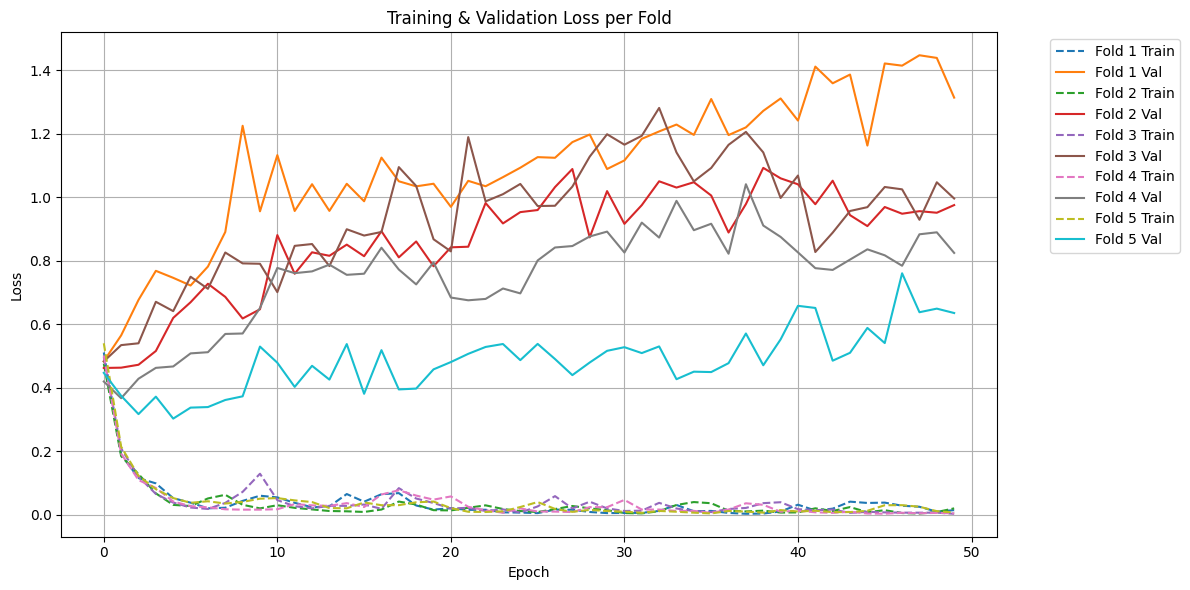

In [19]:
# --- VISUALIZACIÓN DE PÉRDIDAS (LOSS) ---
plt.figure(figsize=(12, 6))

for i, history in enumerate(history_per_fold):
    plt.plot(history['train_loss'], linestyle='--', label=f'Fold {i+1} Train')
    plt.plot(history['val_loss'], label=f'Fold {i+1} Val')

plt.title('Training & Validation Loss per Fold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


--- Entrenando Modelo Final en todo Train+Val para evaluar en Test ---


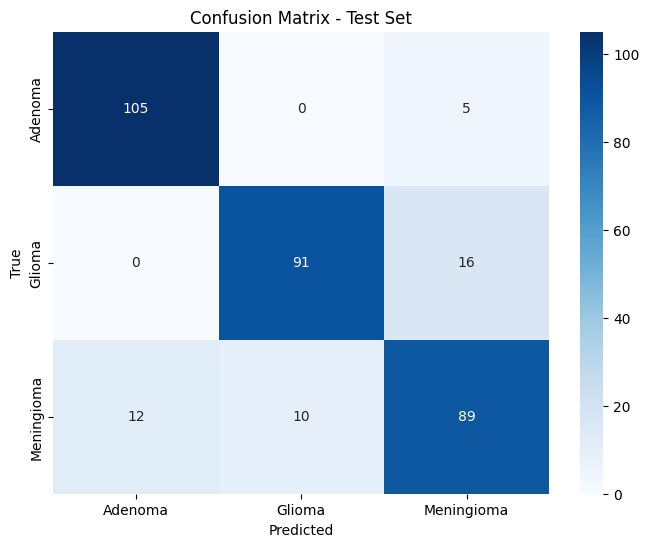


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

     Adenoma       0.90      0.95      0.93       110
      Glioma       0.90      0.85      0.88       107
  Meningioma       0.81      0.80      0.81       111

    accuracy                           0.87       328
   macro avg       0.87      0.87      0.87       328
weighted avg       0.87      0.87      0.87       328



In [20]:
# --- EVALUACIÓN FINAL EN TEST SET ---
# Entrenamos un modelo final con todo el set de Train/Validation o usamos el mejor del CV
# Para este reporte, re-entrenaremos en todo X_train_val para evaluar en X_test

print("\n--- Entrenando Modelo Final en todo Train+Val para evaluar en Test ---")

full_train_ds = TensorDataset(X_train_val, y_train_val)
full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_ds = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

final_model = RedNeuronalGeneral(input_shape=X_all.shape[1:], num_classes=3).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    final_model.train()
    for inputs, labels in full_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# Evaluación
final_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- MATRIZ DE CONFUSIÓN Y REPORTE ---
cm = confusion_matrix(all_labels, all_preds)
class_names = list(class_map.keys()) if 'class_map' in locals() else ['Adenoma', 'Glioma', 'Meningioma'] # Fallback names if map missing context

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()

print("\n--- Classification Report (Test Set) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))